# Drug-likeness and ADMET prediction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yboulaamane/cadd-labs/blob/main/admet_druglikeness.ipynb)

Most drug candidates fail not because they miss the target, but because of ADMET: a molecule
that is poorly absorbed, never reaches the tissue, is cleared too fast or is toxic will not make
it, however well it binds. The earlier you can spot those risks, the cheaper they are to avoid.

**What you'll do**

- Score a set of compounds on **physicochemical rules** (Lipinski, Veber) and the QED drug-likeness score.
- Flag reactive or assay-interfering groups with **structural alerts** (PAINS, Brenk).
- Predict around 40 **ADMET endpoints** with [ADMET-AI](https://github.com/swansonk14/admet_ai):
  blood-brain barrier, hERG, CYP inhibition, mutagenicity, solubility and more.

The example set is MAO-B inhibitors (a brain target, so crossing the blood-brain barrier matters)
plus natural coumarins and, on purpose, one notorious frequent-hitter. Swap in your own SMILES.

Runtime: CPU is fine.

## Setup

RDKit for the descriptors and alerts; ADMET-AI for the predictions (its models ship with the package).

In [ ]:
%pip install -q rdkit admet-ai seaborn

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "savefig.bbox": "tight"})
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Draw, QED
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

RDLogger.DisableLog("rdApp.*")
pd.set_option("display.max_columns", None)

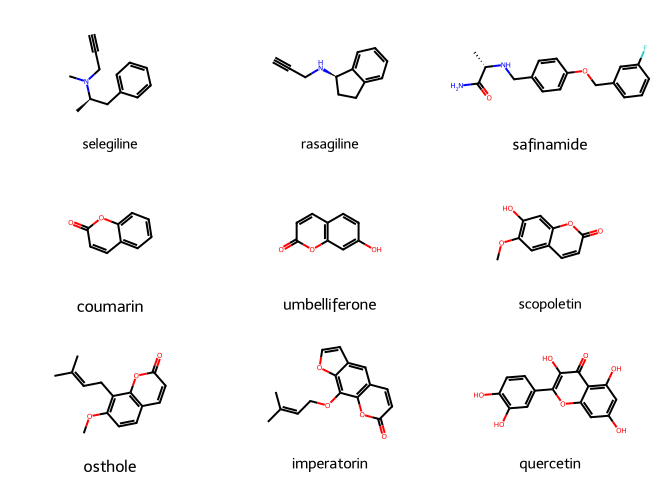

In [3]:
compounds = {
    "selegiline": "C#CCN(C)[C@H](C)Cc1ccccc1",
    "rasagiline": "C#CCN[C@@H]1CCc2ccccc21",
    "safinamide": "C[C@H](NCc1ccc(OCc2cccc(F)c2)cc1)C(N)=O",
    "coumarin": "O=c1ccc2ccccc2o1",
    "umbelliferone": "O=c1ccc2ccc(O)cc2o1",
    "scopoletin": "COc1cc2ccc(=O)oc2cc1O",
    "osthole": "COc1ccc2ccc(=O)oc2c1CC=C(C)C",
    "imperatorin": "CC(C)=CCOc1c2occc2cc2ccc(=O)oc12",
    "quercetin": "O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12",
}
frame = pd.DataFrame({"compound": list(compounds), "smiles": list(compounds.values())})
frame["mol"] = frame["smiles"].map(Chem.MolFromSmiles)
Draw.MolsToGridImage(list(frame["mol"]), legends=list(frame["compound"]), molsPerRow=3, subImgSize=(220, 160))

## 1. Physicochemical rules

Lipinski's rule of five and Veber's rules are rough filters for oral drug-likeness. They are
guides, not laws: many approved drugs break one, and CNS drugs tend to be smaller and less
polar than the limits. QED rolls several properties into one 0-to-1 desirability score.

In [4]:
def properties(mol):
    return pd.Series({
        "MW": Descriptors.MolWt(mol),
        "cLogP": Descriptors.MolLogP(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotB": Descriptors.NumRotatableBonds(mol),
        "QED": QED.qed(mol),
    })


props = frame["mol"].apply(properties)


def lipinski_violations(row):
    return int(row.MW > 500) + int(row.cLogP > 5) + int(row.HBD > 5) + int(row.HBA > 10)


props["Lipinski_viol"] = props.apply(lipinski_violations, axis=1)
props["Veber_pass"] = (props.RotB <= 10) & (props.TPSA <= 140)
props.insert(0, "compound", frame["compound"])
props.round(2)

,compound,MW,cLogP,HBD,HBA,TPSA,RotB,QED,Lipinski_viol,Veber_pass
0,selegiline,187.29,2.18,0.0,1.0,3.24,4.0,0.65,0,True
1,rasagiline,171.24,1.90,1.0,1.0,12.03,2.0,0.67,0,True
2,safinamide,302.35,2.37,2.0,3.0,64.35,7.0,0.83,0,True
3,coumarin,146.14,1.79,0.0,2.0,30.21,0.0,0.53,0,True
4,umbelliferone,162.14,1.50,1.0,3.0,50.44,0.0,0.60,0,True
5,scopoletin,192.17,1.51,1.0,4.0,59.67,1.0,0.70,0,True
6,osthole,244.29,3.31,0.0,3.0,39.44,3.0,0.61,0,True
7,imperatorin,270.28,3.88,0.0,4.0,52.58,3.0,0.53,0,True
8,quercetin,302.24,1.99,5.0,7.0,131.36,1.0,0.43,0,True


## 2. Structural alerts

PAINS flags substructures that often show up as false positives in assays; Brenk flags
reactive or otherwise undesirable groups. A hit is a reason to look closely, not an automatic
rejection. Quercetin, included on purpose, carries a catechol that both catalogs flag.

In [5]:
params = FilterCatalogParams()
for name in ("PAINS", "BRENK"):
    params.AddCatalog(getattr(FilterCatalogParams.FilterCatalogs, name))
catalog = FilterCatalog(params)


def alerts(mol):
    hits = catalog.GetMatches(mol)
    labels = [f"{h.GetProp('FilterSet')}: {h.GetDescription()}" for h in hits]
    return pd.Series({"n_alerts": len(labels), "alerts": "; ".join(labels)})


frame.join(frame["mol"].apply(alerts))[["compound", "n_alerts", "alerts"]]

,compound,n_alerts,alerts
0,selegiline,1,Brenk: triple_bond
1,rasagiline,1,Brenk: triple_bond
2,safinamide,0,
3,coumarin,1,Brenk: cumarine
4,umbelliferone,1,Brenk: cumarine
5,scopoletin,1,Brenk: cumarine
6,osthole,2,Brenk: cumarine; Brenk: isolated_alkene
7,imperatorin,2,Brenk: cumarine; Brenk: isolated_alkene
8,quercetin,2,PAINS_B: catechol_A(92); Brenk: catechol


## 3. Machine-learned ADMET

ADMET-AI predicts about 40 endpoints with models trained on the Therapeutics Data Commons.
The first cell loads the models (a few seconds); the second predicts. Below is a readable
subset; `predictions` holds them all.

In [6]:
from admet_ai import ADMETModel

model = ADMETModel()
predictions = model.predict(smiles=list(compounds.values()))
predictions.index = list(compounds)
print(f"{predictions.shape[1]} endpoints predicted")

104 endpoints predicted


A few that matter for a CNS drug. Classification columns are probabilities from 0 to 1;
`BBB_Martins` is the chance of crossing the blood-brain barrier (higher is better here),
while `hERG`, `AMES` and `DILI` are risk flags (lower is better). `Solubility_AqSolDB` is
log mol/L and `Caco2_Wang` is log permeability.

In [7]:
endpoints = {
    "BBB_Martins": "BBB (higher=crosses)",
    "hERG": "hERG risk",
    "AMES": "Ames mutagenicity",
    "DILI": "Liver injury",
    "CYP2D6_Veith": "CYP2D6 inhibition",
    "CYP3A4_Veith": "CYP3A4 inhibition",
    "Solubility_AqSolDB": "Solubility (logS)",
    "Caco2_Wang": "Caco-2 perm.",
}
predictions[list(endpoints)].rename(columns=endpoints).round(2)

,BBB (higher=crosses),hERG risk,Ames mutagenicity,Liver injury,CYP2D6 inhibition,CYP3A4 inhibition,Solubility (logS),Caco-2 perm.
selegiline,0.97,0.72,0.12,0.05,0.80,0.02,-2.88,-4.28
rasagiline,0.95,0.50,0.58,0.15,0.49,0.04,-1.40,-4.34
safinamide,0.89,0.86,0.49,0.51,0.63,0.62,-3.25,-4.81
coumarin,0.98,0.06,0.09,0.68,0.01,0.00,-2.00,-4.07
umbelliferone,0.64,0.12,0.19,0.71,0.08,0.05,-1.76,-4.42
scopoletin,0.78,0.14,0.23,0.76,0.05,0.06,-2.15,-4.43
osthole,0.95,0.52,0.20,0.67,0.20,0.26,-4.83,-4.36
imperatorin,0.93,0.50,0.30,0.82,0.25,0.30,-5.32,-4.31
quercetin,0.05,0.34,0.57,0.91,0.21,0.56,-2.89,-5.56


ADMET-AI also reports where each value falls among approved drugs (its DrugBank percentile),
which puts a raw number in context. The heatmap shows the classification endpoints; a redder
cell means a higher predicted probability.

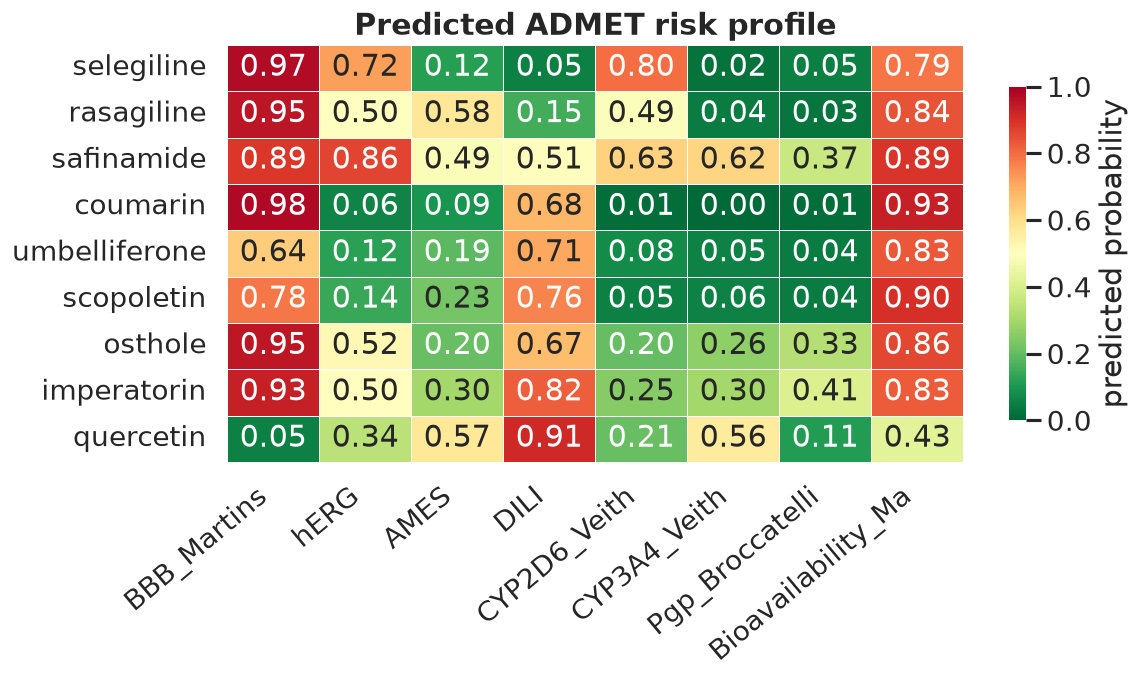

In [8]:
risk = predictions[["BBB_Martins", "hERG", "AMES", "DILI", "CYP2D6_Veith", "CYP3A4_Veith",
                    "Pgp_Broccatelli", "Bioavailability_Ma"]]
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(risk, annot=True, fmt=".2f", cmap="RdYlGn_r", vmin=0, vmax=1,
            linewidths=.5, cbar_kws={"label": "predicted probability", "shrink": .8}, ax=ax)
ax.set_title("Predicted ADMET risk profile")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Takeaways

- No single number decides a compound. ADMET is a *profile*: read the rules, alerts and
  predictions together and weigh them against what the project needs.
- Rules and alerts are heuristics, not verdicts. Plenty of approved drugs break a rule or carry
  a flagged group (the coumarins here trip a Brenk alert); treat a flag as a prompt to look closer.
- The ML predictions are statistics from public data, not measurements. They are great for
  ranking and catching risks early, then you confirm the ones that matter in the lab.
- They are least reliable for chemistry unlike the training data, so unusual natural-product
  scaffolds deserve extra caution.

**Try it yourself:** paste your own SMILES into `compounds` and see which survive all three screens.